In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data=pd.read_csv("C:\\Users\\pooja\\OneDrive\\Desktop\\Documents\\IITM\\DAL\\lab 3\\Assignment3.csv")
data.head()

,x1,x2,x3,x4,x5,y
0,7.11,-447.71,135.66,92.41,96.04,9131.40
1,7.06,-455.33,94.49,91.76,92.16,9001.86
2,6.89,-466.86,186.25,89.54,100.00,8595.85
3,7.25,-440.53,176.83,94.24,84.64,9469.94
4,7.24,-445.92,185.90,94.11,88.36,9448.98


In [3]:
def SSE(y,y_hat):
    return(np.sum((y-y_hat)**2))

In [4]:
#TASK 1: FITTING OLS

df=data
y_1=df['y']
X_1=df.drop(['y'],axis=1)


model_1=LinearRegression()
model_1.fit(X_1,y_1)
beta_1=model_1.coef_
print("beta_1=",beta_1)
y_hat_1=model_1.predict(X_1)
sse_1=SSE(y_1,y_hat_1)
print("SSE_1=",sse_1)
mse_1=mean_squared_error(y_1,y_hat_1)
print("RMSE_1=",np.sqrt(mse_1))

beta_1= [-1.06736899e+03  1.00659916e-01 -5.71765977e-02  2.84363302e+02
  1.62848730e+00]
SSE_1= 71877.84134016898
RMSE_1= 26.67698999975855


### The OLS solution gives us a very high SSE for the dataset. This implies that maybe linear model is NOT a good fit for our data. We can convert this problem from a 2-dimension (the dimensions in which we solve linear regression problems) to a problem in a higher dimension. We can also transform the variables in a way that we get a better solution in the linear regression space.

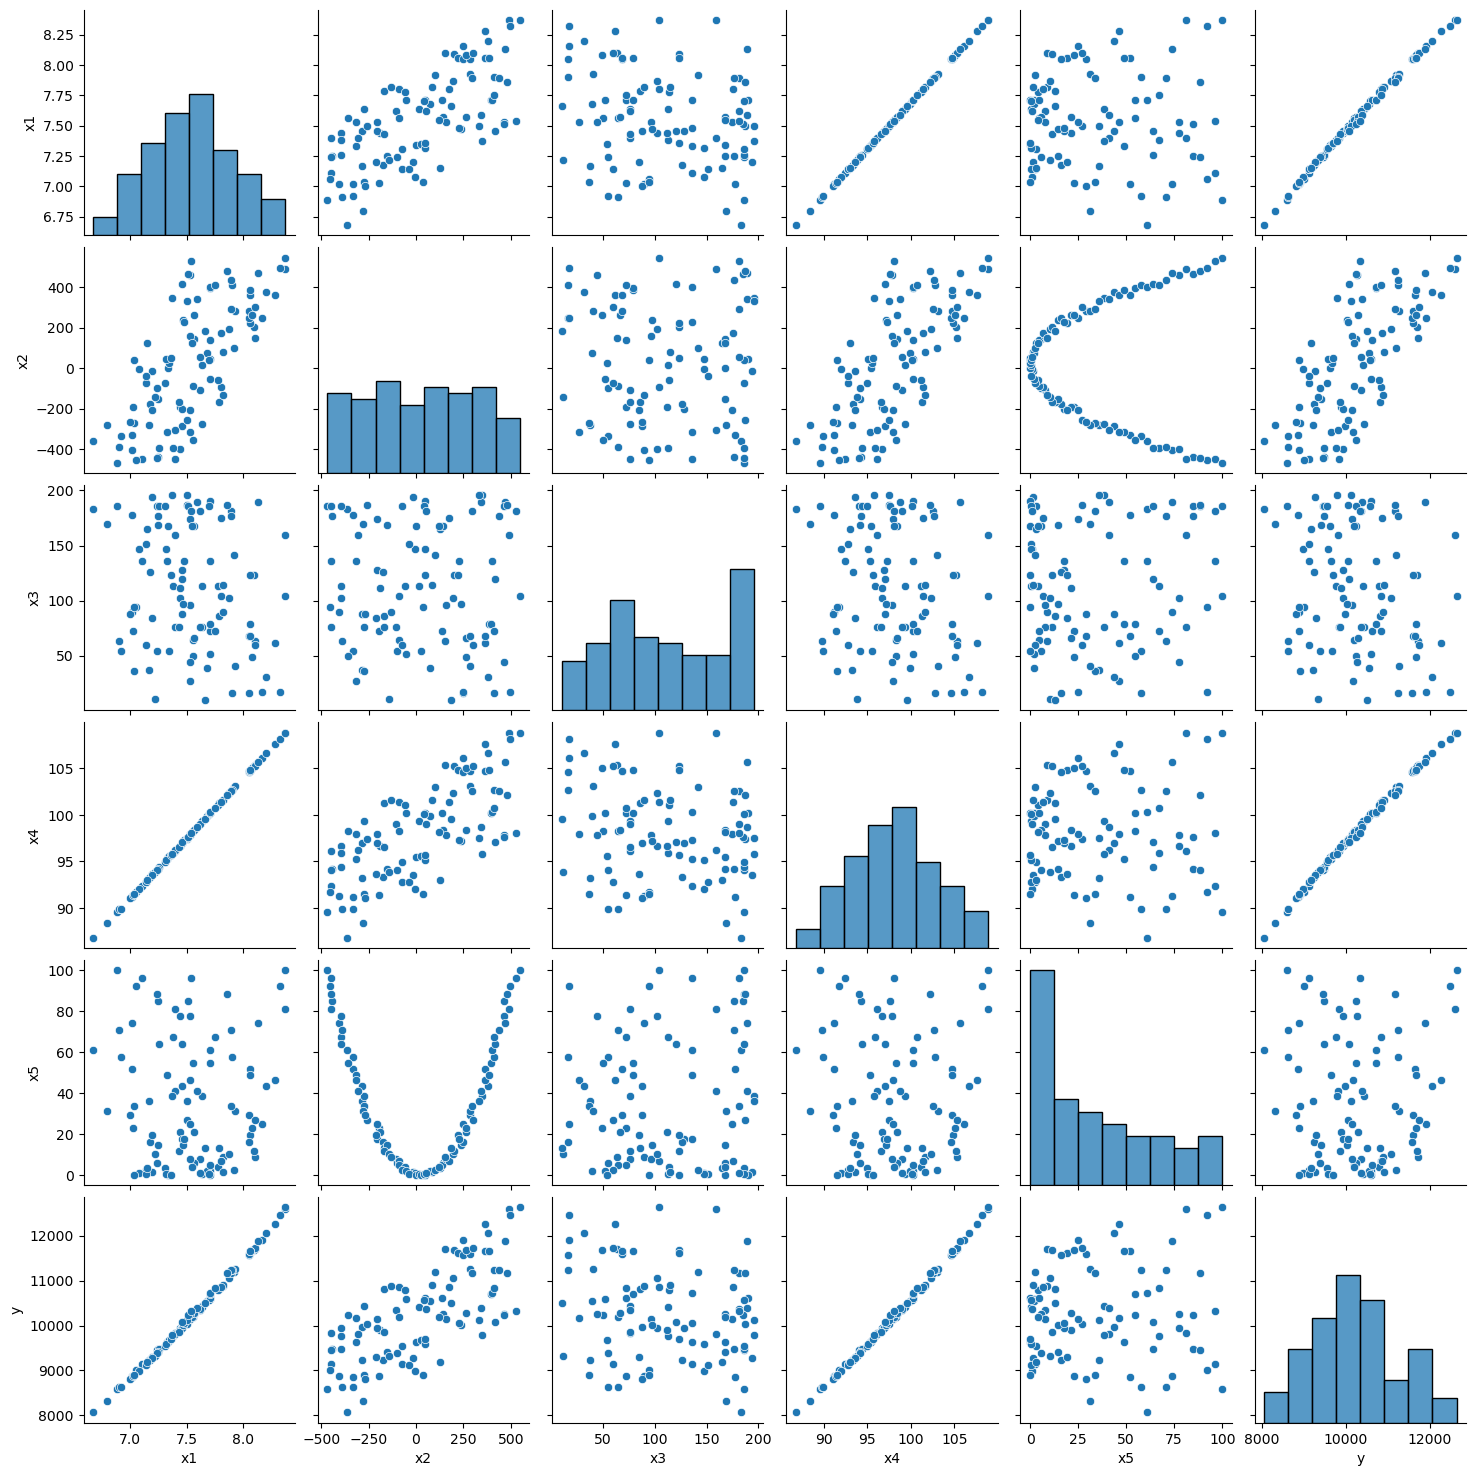

In [5]:
#TASK 2: EDA

sns.pairplot(data)
plt.show()

In [6]:

corr_mat=data.corr()
corr_mat

,x1,x2,x3,x4,x5,y
x1,1.000000,0.702276,-0.223697,0.999978,-0.001449,0.998214
x2,0.702276,1.000000,-0.032603,0.703196,0.002613,0.716703
x3,-0.223697,-0.032603,1.000000,-0.224808,0.081322,-0.220265
x4,0.999978,0.703196,-0.224808,1.000000,-0.001777,0.998266
x5,-0.001449,0.002613,0.081322,-0.001777,1.000000,0.046610
y,0.998214,0.716703,-0.220265,0.998266,0.046610,1.000000


### Interpretations:
1. From histograms-

a. Variables X1, X4 and y are approximately normally distributed, i.e, maximum points lie near the mean of the datapoints and number points near the tail of the distribution decrease. This implies that their central tendencies can be a used to change the origin of these variables. It is also easier to transform these variables as they follow the assumption for formulation of linear models (noise is normally distributed).

b. Variable X2 is approximately uniformily distributed. That means, that the datapoints are equally distributed within its range. We can apply quantile transformation or minimax scaling to this variable.
c. Variables X3 and X5 are skewed with longer left and right tails, respectively. As they deviate from the normal distribution, these variables can effect the model performance.

2. From Scatter plots and correlation matrix-

a.Variables (X1 and X2) and (X2 and X4) seem to have some sort of linear relationship with a positive slope (have a positive correlation).  Variables(X1 and X4) have a perfect linear relationship (correlation nearly=1). This can also be verified from the correlation matrix. This correlation effect model performance negatively. 

b. Variables X2 and X5 have a near perfect quadratic relationship. Hence, even though they have a low value of correlation, they are not independent variables, and effect the model performance.

c. X3 does not have any discernable relationship with any of the features.

d. y has a linear relationship with X1, X2 and X4. This means that these variables will have a higher coefficient as compare to X3 and X5 in the regression model.

### Feature Selection:

To reduce multicollinearity of the data and improve model performance, we can lose redundant variables. Since X1 and X4 are nearly perfectly correlated, we can drop either X1 or X4. 
Moreover, X2 and X5 have a quadratic relationship. That means the regression model needs to be constructed in atleast second degree.

In [7]:
df=data

y_2=df['y']
X_2=df.drop(['x1','y'],axis=1)

poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X_2)

model_2=LinearRegression()
model_2.fit(X_poly,y_2)
y_hat_2=model_2.predict(X_poly)
sse_2=SSE(y_2,y_hat_2)
print("SSE_2=",sse_2)
mse_2=mean_squared_error(y_2,y_hat_2)
print("RMSE_2=",np.sqrt(mse_2))

feature_names = poly.get_feature_names_out(['x2','x3', 'x4', 'x5'])

beta_2=model_2.coef_
for i in range(len(beta_2)):
    print("feature: {}, coefficient:{}, Significant:{}".format(feature_names[i],beta_2[i],("No" if abs(beta_2[i])<1 else "Yes")))

SSE_2= 35.13157636655325
RMSE_2= 0.5897774069662672
feature: 1, coefficient:0.0, Significant:No
feature: x2, coefficient:0.1175426665365341, Significant:No
feature: x3, coefficient:-0.014953778501455852, Significant:No
feature: x4, coefficient:4.70790989712584, Significant:Yes
feature: x5, coefficient:1.1381591140757463, Significant:Yes
feature: x2^2, coefficient:5.14736438583796e-06, Significant:No
feature: x2 x3, coefficient:-5.147585328900417e-06, Significant:No
feature: x2 x4, coefficient:-0.00016581860199726267, Significant:No
feature: x2 x5, coefficient:-2.676194729853837e-05, Significant:No
feature: x3^2, coefficient:2.4834431051985392e-05, Significant:No
feature: x3 x4, coefficient:9.259994584068232e-05, Significant:No
feature: x3 x5, coefficient:2.575231527801765e-05, Significant:No
feature: x4^2, coefficient:1.0039257712789926, Significant:Yes
feature: x4 x5, coefficient:0.0015566463798319472, Significant:No
feature: x5^2, coefficient:-5.6032714895441586e-05, Significant:No


### From the above model, it is observed that only x4, x5 and x4^2 are significant to the model. Moreover, x2 has a sgnificant correlation with y, so it can be included in the model as well.

In [8]:
#TASK 3: 

df=data
df['x4^2']=df['x4']**2
y_3=df['y']
X_3=df.drop(['x1','x3','y'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_3, y_3, test_size=0.2, random_state=22)

model_3=LinearRegression()
model_3.fit(X_train,y_train)
beta_3=model_3.coef_
print("beta_3={}, bias={}".format(beta_3,model_3.intercept_))

print("For TEST DATA:")
y_hat_3_test=model_3.predict(X_test)
sse_3_test=SSE(y_test,y_hat_3_test)
mse_3_test=mean_squared_error(y_test,y_hat_3_test)
print("SSE={}, RMSE={}".format(sse_3_test,np.sqrt(mse_3_test)))

print("For TRAIN DATA:")
y_hat_3_train=model_3.predict(X_train)
sse_3_train=SSE(y_train,y_hat_3_train)
mse_3_train=mean_squared_error(y_train,y_hat_3_train)
print("SSE={}, RMSE={}".format(sse_3_train,np.sqrt(mse_3_train)))


beta_3=[0.09969428 5.45963774 1.29977866 1.00043111], bias=3.494376249926063
For TEST DATA:
SSE=7.735696757888884, RMSE=0.606932049145885
For TRAIN DATA:
SSE=32.170189149596816, RMSE=0.6341351310012403


#### The loss has decreased as compared to earlier OLS model, so this is a better model for our data.
#### MODEL: y = 3.494 + 0.0996x2 + 5.459x4 + 1.299x5 + x4^2
#### As RMSE for train and test data is approximately the same, there is no overfitting.

In [9]:
#!pip install lazypredict

In [10]:
from lazypredict.Supervised import LazyRegressor 

In [11]:
df=data

y_4=df['y']
X_4=df.drop('y', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_4, y_4, test_size=0.2, random_state=22)

model_4=LazyRegressor()
model=model_4.fit(X_train, X_test, y_train, y_test)

print(model)

100%|██████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 15.84it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 162
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 6
[LightGBM] [Info] Start training from score 10293.768042
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

### From the RMSE values obtained from lazy regressor, we can see that-
1. Least RMSE obtained from lazyregressor is the RMSE obtained from the OLS model, so the model fitted through OLS is a good fit.
2. As Adjusted R-square decreases and RMSE increases for the various regressors present, we can conclude that these models are not a good fit. A reason why some models perform badly can be attributed to the fact that these models are overly complex for a fairly small dataset. Moreover, their default hyperparameters might be influencing model building in an adverse way, leading to larger errors.